In [4]:
# M*xs + C = 0 form
import numpy as np
from numba import jit
from random import random as rand


## M * dx + C = 0

@jit
def Mfcn(t,xs,ps): # mass matrix for dynamics
    σ1, σ2, σ3, σr, σg, ψ, ϑ, φ, r, γ, xG, yG = xs
    g, R, mw, JW1, JW2, mr, JR, BR, h, mp, JPx, JPy, JPz, BP = ps
    sin,cos,tan=np.sin,np.cos,np.tan
    M = np.zeros((5,5))

    M[0,0] = JPz + JR + JW2 + R**2*mp + R**2*mw + 2*R*h*mp*cos(γ) + mr*r**2 + (JPx - JPz + h**2*mp)*cos(γ)**2
    M[0,2] = -R*h*mp*sin(γ) + (-JPx + JPz - h**2*mp)*sin(γ)*cos(γ)
    M[2,0] = M[0,2]
    M[1,1] = JW1 + R**2*mp + R**2*mr + R**2*mw
    M[1,2] = -R*mr*r
    M[2,1] = M[1,2]
    M[1,4] = R*h*mp*cos(γ)
    M[4,1] = M[1,4]
    M[2,2] = JPz + JR + JW2 + mr*r**2 + (JPx - JPz + h**2*mp)*sin(γ)**2
    M[3,3] = mr
    M[4,4] = JPy + h**2*mp
    return M

@jit
def Cfcn(t,xs,ps,us): # dynamics including all forces (control as well) + kinematics 
    σ1, σ2, σ3, σr, σg, ψ, ϑ, φ, r, γ, xG, yG = xs
    g, R, mw, JW1, JW2, mr, JR, BR, h, mp, JPx, JPy, JPz, BP = ps
    sin,cos,tan=np.sin,np.cos,np.tan
    F1, M2 = us
    C = np.empty(12)

    # dynamics part
    C[0] = BR*R**2*σ1 + BR*R*σr + F1*R - R*g*(mp + mw)*sin(ϑ) + R*mr*r*σ1**2 - g*h*mp*sin(ϑ)*cos(γ) + g*mr*r*cos(ϑ) + 2*mr*r*σ1*σr + σ1*σ3*(R*h*mp*sin(γ)*tan(ϑ) + (JPx - JPz + h**2*mp)*sin(γ)*cos(γ)*tan(ϑ)) + σ1*σg*(-2*R*h*mp*sin(γ) - 2*(JPx - JPz + h**2*mp)*sin(γ)*cos(γ)) + σ2*σ3*(-JW1 - R**2*mp - R**2*mw - R*h*mp*cos(γ) - R*mr*r*tan(ϑ)) + σ3**2*(R*h*mp*cos(γ)*tan(ϑ) + mr*r**2*tan(ϑ) + (JPx - JPz + h**2*mp)*cos(γ)**2*tan(ϑ) + (JPz + JR + JW2)*tan(ϑ)) + σ3*σg*(JPx - JPy - JPz - 2*R*h*mp*cos(γ) - 2*(JPx - JPz + h**2*mp)*cos(γ)**2)
    C[1] = BP*σ2 - BP*σg - M2 - R*h*mp*σ3**2*sin(γ) - R*h*mp*σg**2*sin(γ) - 2*R*mr*σ3*σr + σ1*σ3*(R**2*(mp - mr + mw) + R*h*mp*cos(γ) + R*mr*r*tan(ϑ))
    C[2] = JW1*σ1*σ2 + R*h*mp*σ2*σ3*sin(γ) + g*h*mp*sin(γ)*sin(ϑ) + 2*mr*r*σ3*σr + σ1*σ3*(R*mr*r - mr*r**2*tan(ϑ) + (-JPx + JPz - h**2*mp)*sin(γ)**2*tan(ϑ) + (-JPz - JR - JW2)*tan(ϑ)) + σ1*σg*(-JPx + JPy + JPz + 2*(JPx - JPz + h**2*mp)*sin(γ)**2) + σ3**2*(-JPx + JPz - h**2*mp)*sin(γ)*cos(γ)*tan(ϑ) + 2*σ3*σg*(JPx - JPz + h**2*mp)*sin(γ)*cos(γ)
    C[3] = BR*R*σ1 + BR*σr + F1 + R*mr*σ2*σ3 + g*mr*sin(ϑ) - mr*r*σ1**2 - mr*r*σ3**2
    C[4] = -BP*σ2 + BP*σg + M2 + R*h*mp*σ2*σ3*sin(γ)*tan(ϑ) - g*h*mp*sin(γ)*cos(ϑ) + σ1**2*(R*h*mp*sin(γ) + (JPx - JPz + h**2*mp)*sin(γ)*cos(γ)) + σ1*σ3*(JPx - JPz + R*h*mp*cos(γ) + h**2*mp - 2*(JPx - JPz + h**2*mp)*sin(γ)**2) + σ3**2*(-JPx + JPz - h**2*mp)*sin(γ)*cos(γ)

    #kinematics
    C[5]  = -σ3/cos(ϑ)
    C[6]  = -σ1
    C[7]  = -σ2 + σ3*tan(ϑ)
    C[8]  = -R*σ1 - σr
    C[9]  = σ3*tan(ϑ) - σg
    C[10] = -R*σ1*sin(ψ)*cos(ϑ) - R*σ2*cos(ψ)
    C[11] = R*σ1*cos(ψ)*cos(ϑ) - R*σ2*sin(ψ)

    return C

@jit
def control(t,xs,ps): 
    σ1, σ2, σ3, σr, σg, ψ, ϑ, φ, r, γ, xG, yG = xs
    g, R, mw, JW1, JW2, mr, JR, BR, h, mp, JPx, JPy, JPz, BP = ps
    sin,cos,tan=np.sin,np.cos,np.tan

    F1 = 0 # lateral controller
    M2 = 0 # logitudinal controller
    return np.array([F1,M2])

@jit
def dqs(xs,ps):
    σ1, σ2, σ3, σr, σg, ψ, ϑ, φ, r, γ, xG, yG = xs
    g, R, mw, JW1, JW2, mr, JR, BR, h, mp, JPx, JPy, JPz, BP = ps
    sin,cos,tan=np.sin,np.cos,np.tan

    dψ = σ3/cos(ϑ)
    dϑ = σ1
    dφ = σ2 - σ3*sin(ϑ)/cos(ϑ)
    dr = R*σ1 + σr
    dγ = -σ3*sin(ϑ)/cos(ϑ) + σg
    dxG = R*σ1*sin(ψ)*cos(ϑ) + R*σ2*cos(ψ)
    dyG = -R*σ1*cos(ψ)*cos(ϑ) + R*σ2*sin(ψ)

    ret = np.array([dψ,dϑ,dφ,dr,dγ,dxG,dyG])
    return ret

@jit
def dqs2sigmas(dqs,qs,ps):
    dψ,dϑ,dφ,dr,dγ,dxG,dyG = dqs
    ψ, ϑ, φ, r, γ, xG, yG  =  qs
    g, R, mw, JW1, JW2, mr, JR, BR, h, mp, JPx, JPy, JPz, BP = ps
    sin,cos,tan=np.sin,np.cos,np.tan

    σ1 = dϑ
    σ2 = dφ + dψ*sin(ϑ)
    σ3 = dψ*cos(ϑ)
    σr = -R*dϑ + dr
    σg = dγ + dψ*sin(ϑ)

    sigmas = np.array([σ1,σ2,σ3,σr,σg])
    return sigmas 

@jit
def rhs(t,xs,ps): # right hand side for simulation, dynamics : M\(-C[:5]), kinematics: -C
    M   = Mfcn(t,xs,ps)
    us  = control(t,xs,ps)
    ret = -Cfcn(t,xs,ps,us)
    ret[:5] = np.linalg.solve(M,ret[:5])
    return ret

#          | WHEEL                                     | LATERAL ROD           | PENDULUM                                                      |
#      g,  | R,     mw,    JW1 (y),       JW2 (x&z),   | mr,    JR (x&z),   BR,| h,     mp,    JPx,           JPy,           JPz            BP |
psn = [9.81, 0.253, 2.436, 0.09099921839, 0.04591427768, 0.262, 0.00159165, 0.0, 0.025, 2.799, 0.01290418213, 0.02090219895, 0.01118711607, 0.0]
psn = np.array(psn)

In [5]:
rand=np.random.random
tn=rand();xsn=rand(12);
usn = control(tn,xsn,psn)
Mfcn(tn,xsn,psn),Cfcn(tn,xsn,psn,usn),rhs(tn,xsn,psn)

(array([[ 0.48416845,  0.        , -0.00461345,  0.        ,  0.        ],
        [ 0.        ,  0.44285669, -0.02968309,  0.        ,  0.01727475],
        [-0.00461345, -0.02968309,  0.11139728,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ,  0.262     ,  0.        ],
        [ 0.        ,  0.01727475,  0.        ,  0.        ,  0.02265157]]),
 array([-10.54824881,   0.20762696,   0.19781051,   1.9760379 ,
         -0.0599729 ,  -1.49199893,  -0.99858563,   1.10979539,
         -1.16377769,   1.17177306,  -0.10156339,   0.09853696]),
 array([21.77631188, -0.66221188, -1.05032189, -7.54212938,  3.15264827,
         1.49199893,  0.99858563, -1.10979539,  1.16377769, -1.17177306,
         0.10156339, -0.09853696]))

In [6]:
%%timeit tn=rand();xsn=rand(12);psn=rand(14);usn=rand(2);

Mfcn(tn,xsn,psn)
Cfcn(tn,xsn,psn,usn)

The slowest run took 8.32 times longer than the fastest. This could mean that an intermediate result is being cached.
2.8 μs ± 3.25 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [7]:
%%timeit tn=rand();xsn=rand(12);psn=rand(14);usn=rand(2);

rhs(tn,xsn,psn)

1.28 μs ± 15.2 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


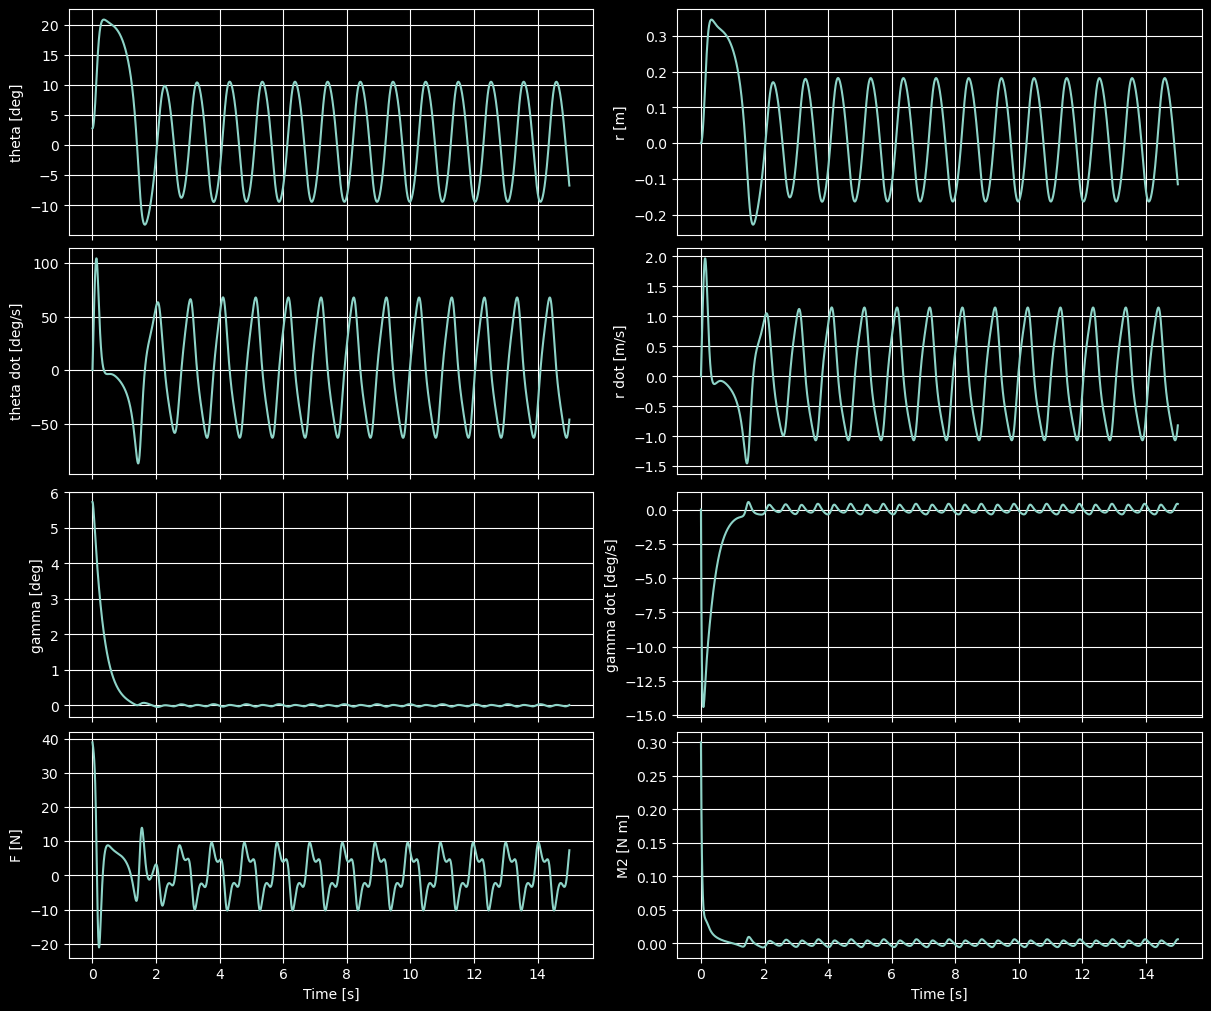

Final sampled time: 15.000 s
Peak |r|: 0.3450 m
Peak |F|: 38.953 N


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# 参数顺序：
# g,R,mw,JW1,JW2,mr,JR,BR,h,mp,JPx,JPy,JPz,BP
p = np.array([
    9.81, 0.253, 2.436, 0.09099921839, 0.04591427768,
    2.3, 0.0517629, 0.0, 0.025, 2.799,
    0.01290418213, 0.02090219895, 0.01118711607, 0.0,
])

# PD 参数，与 MATLAB 默认设置一致
# 状态顺序：[theta, r, theta_dot, r_dot]
K_lat = np.array([
    -797.095497, 854.34418, -103.668186, 105.568949
])
z_ref = np.zeros(4)

kp_gamma, kd_gamma = 3.0, 0.8
gamma_ref, gamma_dot_ref = 0.0, 0.0
force_limit, torque_limit = np.inf, np.inf


def model(t, x, u, p):
    """开环模型：u=[F,M2]；只在这里转换 F1=-F。"""
    F, M2 = u
    C = Cfcn(t, x, p, np.array([-F, M2]))
    return np.r_[
        np.linalg.solve(Mfcn(t, x, p), -C[:5]),
        -C[5:]
    ]


def pd_controller(t, x, p):
    theta_dot = x[0]
    r_dot = p[1] * x[0] + x[3]
    gamma_dot = x[4] - x[2] * np.tan(x[6])

    z = np.array([x[6], x[8], theta_dot, r_dot])
    F = K_lat @ (z_ref - z)

    M2 = (
        kp_gamma * (x[9] - gamma_ref)
        + kd_gamma * (gamma_dot - gamma_dot_ref)
    )

    return np.array([
        np.clip(F, -force_limit, force_limit),
        np.clip(M2, -torque_limit, torque_limit),
    ])


# 初始物理状态
psi0, theta0, phi0 = 0.0, np.deg2rad(2.8), 0.0
r0, gamma0, xG0, yG0 = 0.0, 0.1, 0.0, 0.0
psi_dot0, theta_dot0 = 0.0, 0.0
r_dot0, gamma_dot0 = 0.0, 0.0
forward_speed0 = 0.2  # 轮心前向速度分量 R*sigma2 [m/s]

# x=[sigma1,sigma2,sigma3,sigma_r,sigma_g,
#    psi,theta,phi,r,gamma,xG,yG]
x0 = np.array([
    theta_dot0,
    forward_speed0 / p[1],
    psi_dot0 * np.cos(theta0),
    r_dot0 - p[1] * theta_dot0,
    gamma_dot0 + psi_dot0 * np.sin(theta0),
    psi0, theta0, phi0, r0, gamma0, xG0, yG0,
])

T_end, output_dt, max_step = 15.0, 0.005, 0.005


def tilt_event(t, x):
    return np.deg2rad(80.0) - abs(x[6])


tilt_event.terminal = True
tilt_event.direction = -1
assert tilt_event(0, x0) > 0, "初始侧倾角超过终止阈值"

# 连续时间 PD；output_dt 只是输出间隔
sol = solve_ivp(
    lambda t, x: model(t, x, pd_controller(t, x, p), p),
    (0.0, T_end),
    x0,
    t_eval=np.linspace(
        0, T_end, int(np.ceil(T_end / output_dt)) + 1
    ),
    max_step=max_step,
    rtol=1e-8,
    atol=1e-10,
    events=tilt_event,
)

if not sol.success:
    raise RuntimeError(sol.message)

t, X = sol.t, sol.y.T
U = np.array([
    pd_controller(ti, xi, p) for ti, xi in zip(t, X)
])

r_dot = p[1] * X[:, 0] + X[:, 3]
gamma_dot = X[:, 4] - X[:, 2] * np.tan(X[:, 6])

panels = [
    (np.rad2deg(X[:, 6]), "theta [deg]"),
    (X[:, 8], "r [m]"),
    (np.rad2deg(X[:, 0]), "theta dot [deg/s]"),
    (r_dot, "r dot [m/s]"),
    (np.rad2deg(X[:, 9]), "gamma [deg]"),
    (np.rad2deg(gamma_dot), "gamma dot [deg/s]"),
    (U[:, 0], "F [N]"),
    (U[:, 1], "M2 [N m]"),
]

fig, axes = plt.subplots(
    4, 2, figsize=(12, 10),
    sharex=True, constrained_layout=True
)

for ax, (values, label) in zip(axes.flat, panels):
    ax.plot(t, values)
    ax.set_ylabel(label)
    ax.grid(True)

for ax in axes[-1]:
    ax.set_xlabel("Time [s]")

plt.show()

print(f"Final sampled time: {t[-1]:.3f} s")
print(f"Peak |r|: {np.max(np.abs(X[:, 8])):.4f} m")
print(f"Peak |F|: {np.max(np.abs(U[:, 0])):.3f} N")

if sol.t_events[0].size:
    print(f"Stopped at tilt limit: {sol.t_events[0][0]:.6f} s")